In [1]:
import numpy as np
from funcs import *
import scipy
import h5py
from scipy.fft import *

from nbodykit.lab import *
from nbodykit.lab import ArrayMesh
from nbodykit import style, setup_logging

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.style.use(style.notebook)

In [2]:
setup_logging()

In [2]:
lhid=0
grid = 256
BoxSize=1000.0
voxel_size = np.array(3*[BoxSize/grid])
MAS='cic'
MAS_index=2
compensated=True
interlaced=True
mass=h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijotelike/fastpm/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['mass'][()].astype('float32')
mass=10**mass
pos=h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijotelike/fastpm/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
pos=pos-0.5*BoxSize/128.
np.random.seed(0)
pos += np.random.uniform(-0.5*voxel_size, 0.5*voxel_size, pos.shape)
# pos += 0.5*voxel_size*np.random.randn(*pos.shape)/4
delta=get_delta_nbodykit(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, compensated=compensated, MAS=MAS, interlaced=interlaced)
r = FFTPower(delta, mode='1d')
Pk0 = r.power

pos_target=h5py.File("/anvil/scratch/x-abairagi/cmass-ili/quijote/nbody/L1000-N128/"+str(lhid)+"/halos.h5")['0.666667']['pos'][()].astype('float32')
# pos_target=high_res_pos(pos_target, n=2)
delta_target=get_delta_nbodykit(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=1000.0, compensated=compensated, MAS=MAS, interlaced=interlaced)
r = FFTPower(delta_target, mode='1d')
Pk0_target = r.power

In [3]:
delta_=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS='CIC', verbose=True)
k_, Pk0_, _, _ = compute_Pk(delta_, BoxSize=1000.0, MAS='CIC', axis=0, verbose=True)


Using CIC mass assignment scheme
Time taken = 0.030 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.77 seconds


In [4]:
compensated=False
interlaced=False
delta=get_delta_nbodykit(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, compensated=compensated, MAS=MAS, interlaced=interlaced)
r = FFTPower(delta, mode='1d')
Pk0_default = r.power

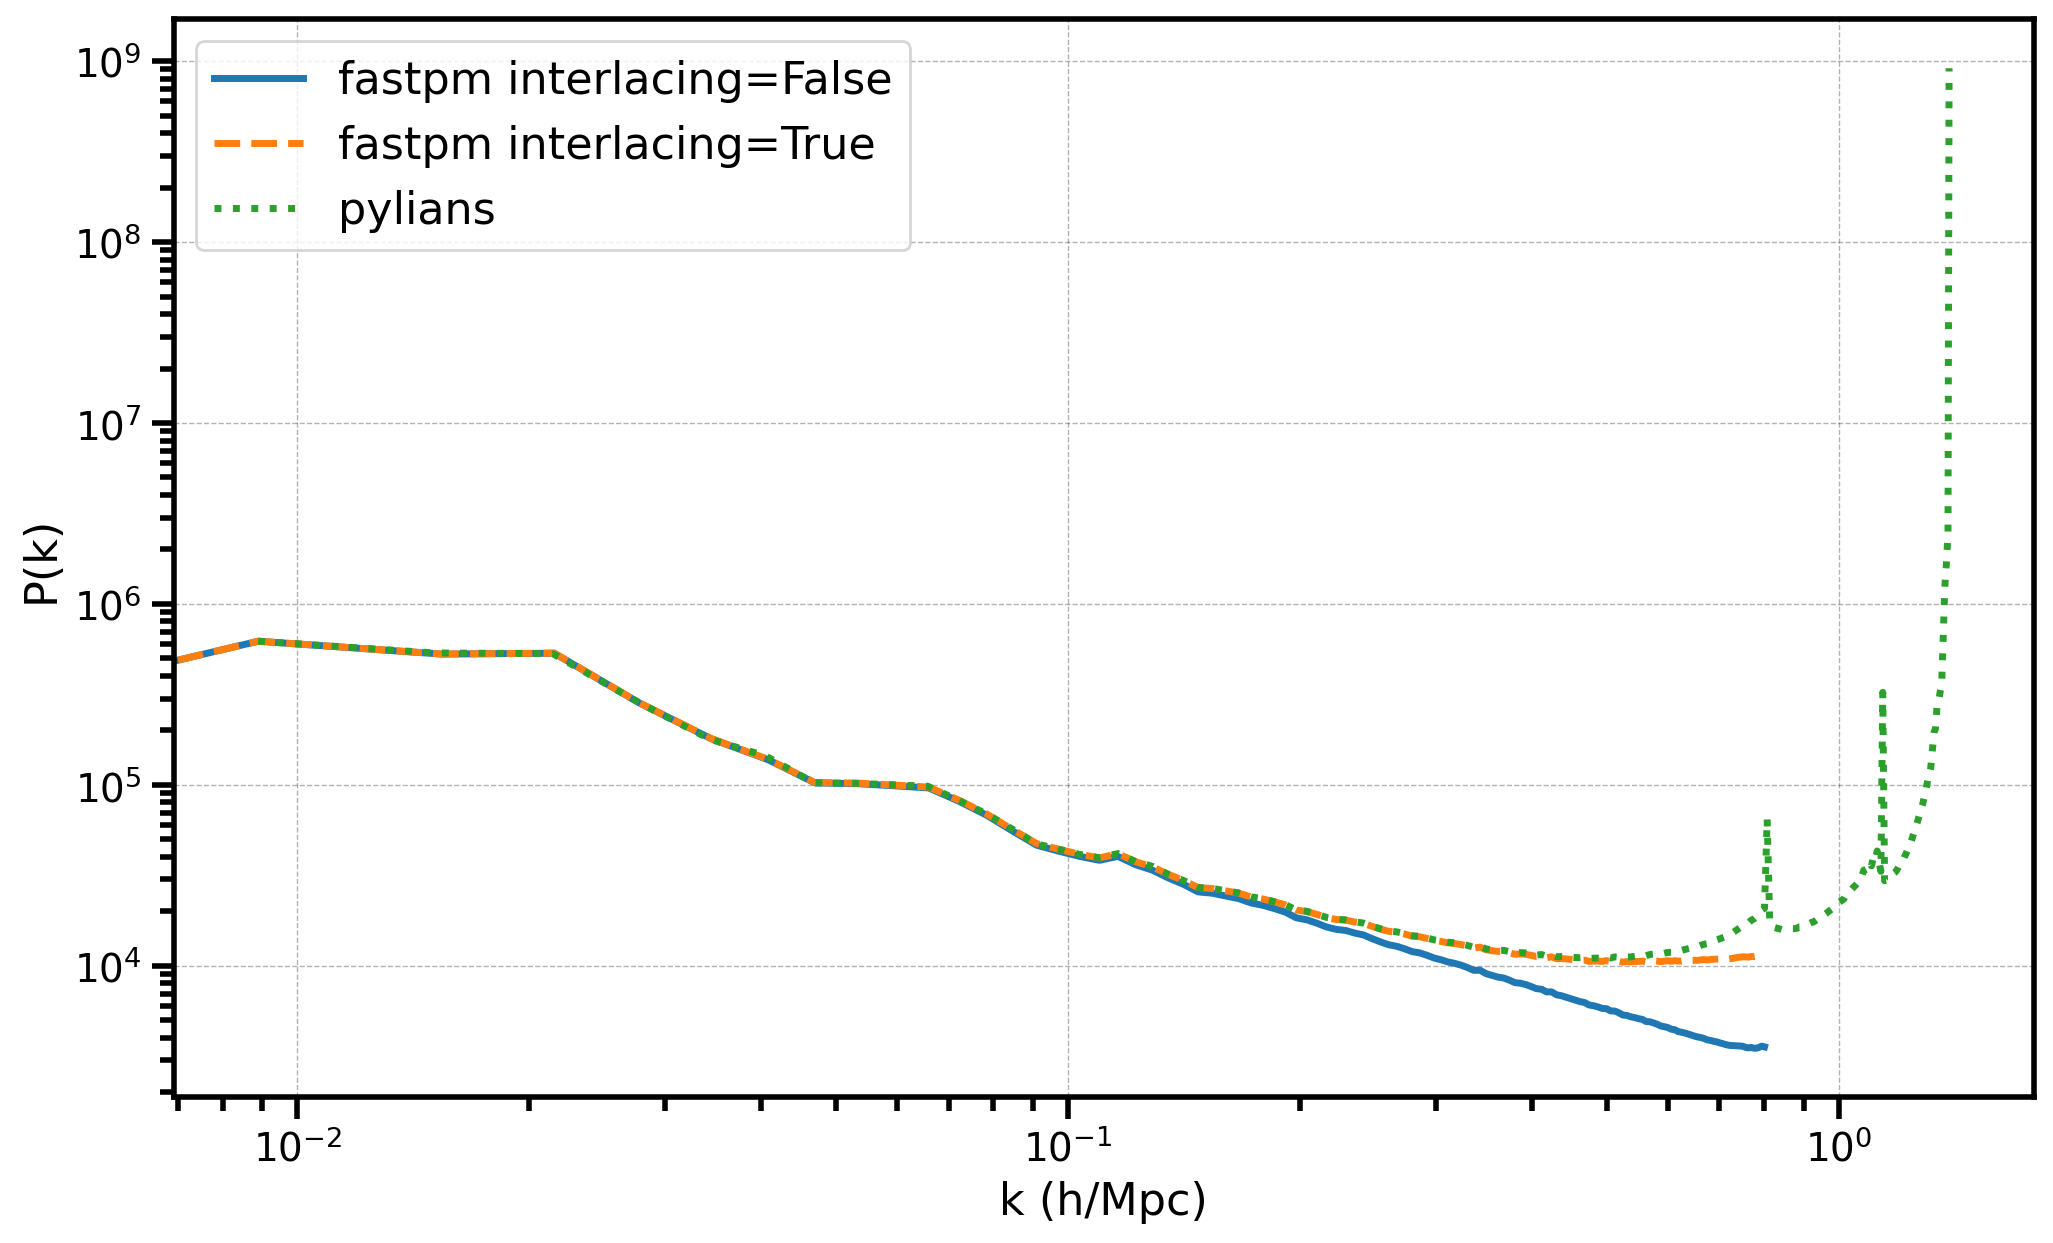

In [38]:
plt.plot(Pk0_default['k'], Pk0_default['power'].real, ls='-',label='fastpm interlacing=False')
plt.plot(Pk0['k'], Pk0['power'].real, ls='--',label='fastpm interlacing=True')
plt.plot(k_, Pk0_, ls=':', label='pylians')
plt.loglog()
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
plt.legend()
# plt.ylim([3000,50000])

In [4]:
ind=111
k=Pk0['k'][1:ind]
Pk0=Pk0['power'].real[1:ind]
k_target=Pk0_target['k'][1:ind]
Pk0_target=Pk0_target['power'].real[1:ind]

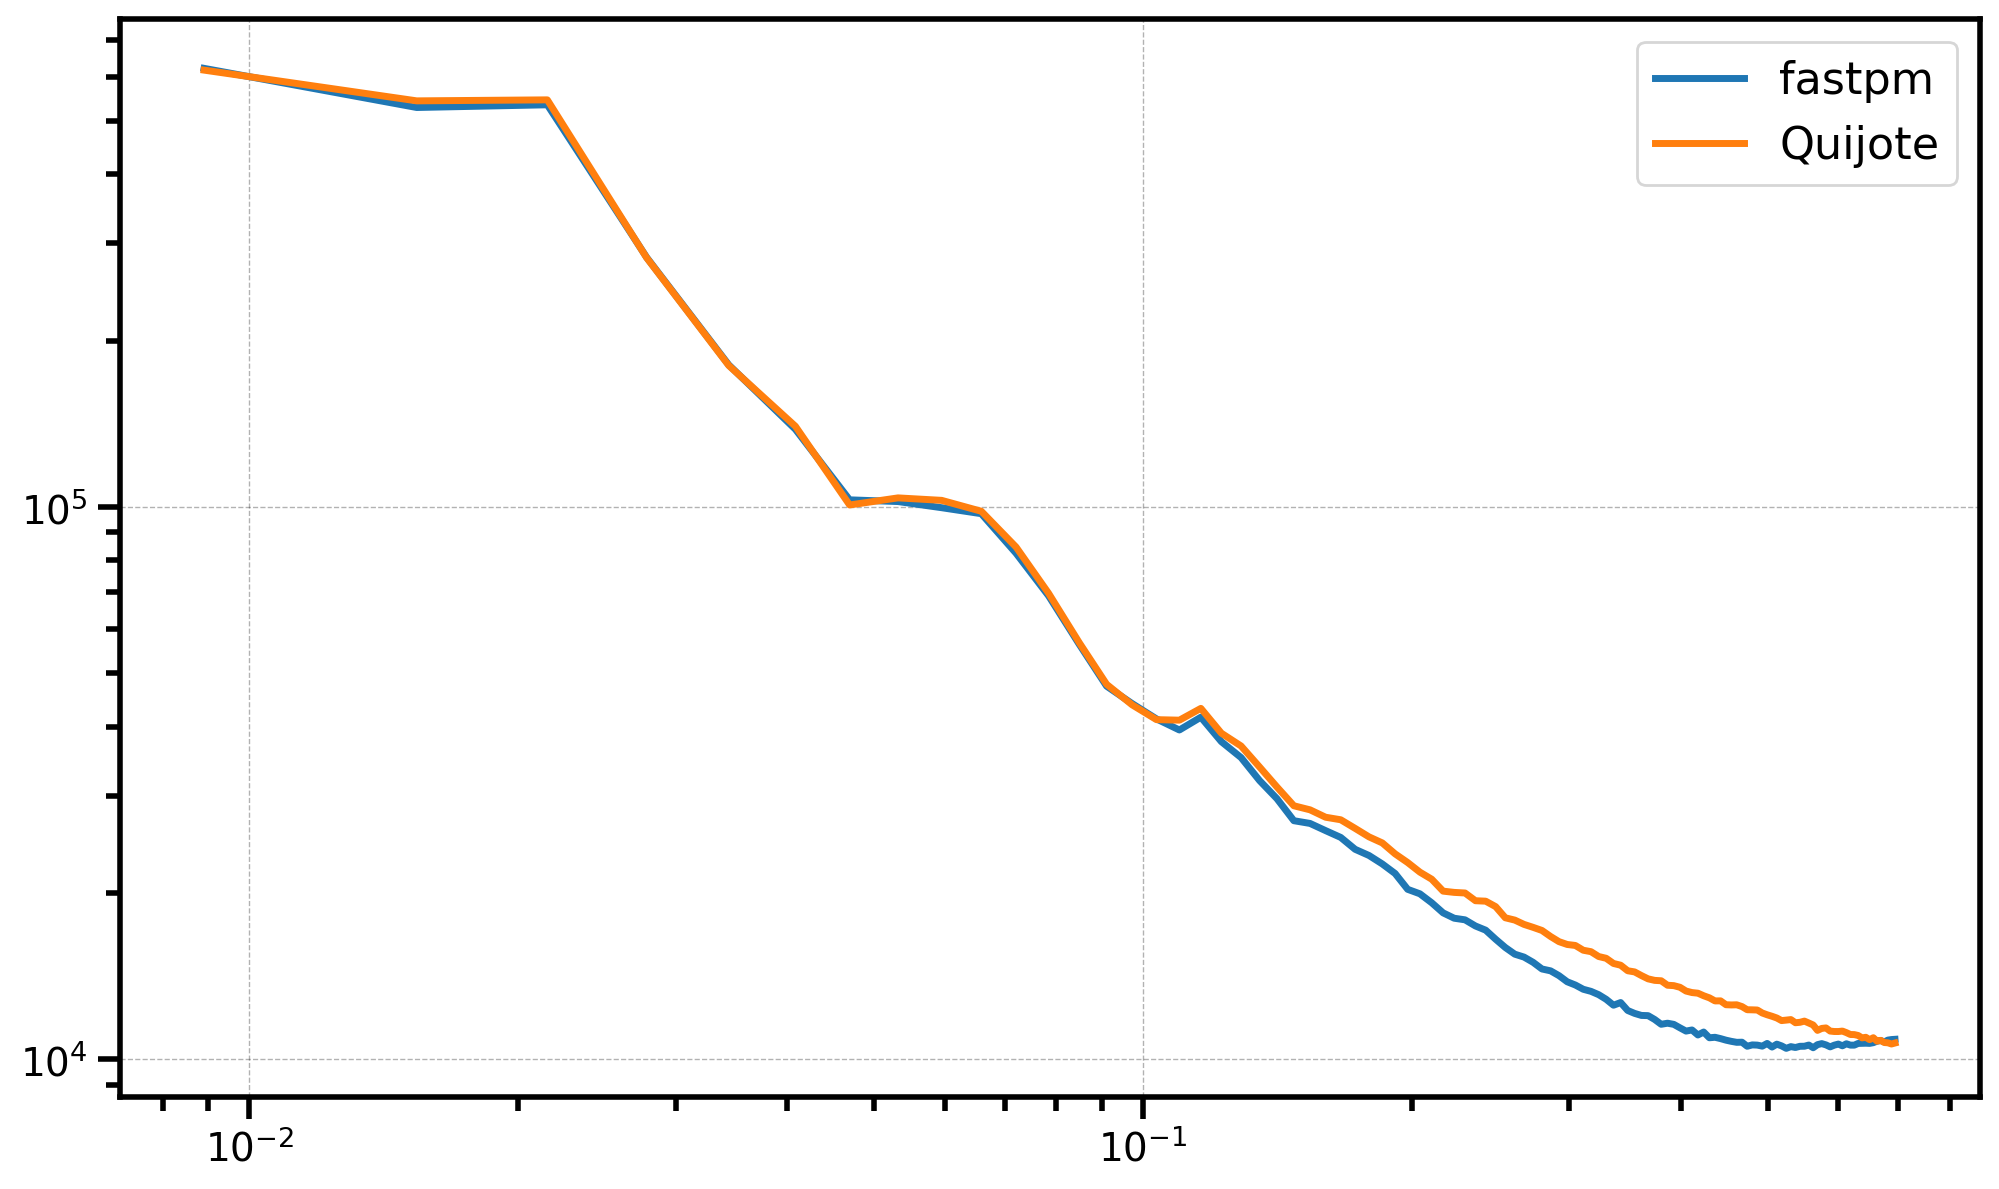

In [6]:
plt.plot(k, Pk0, label='fastpm')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.loglog()
plt.legend()

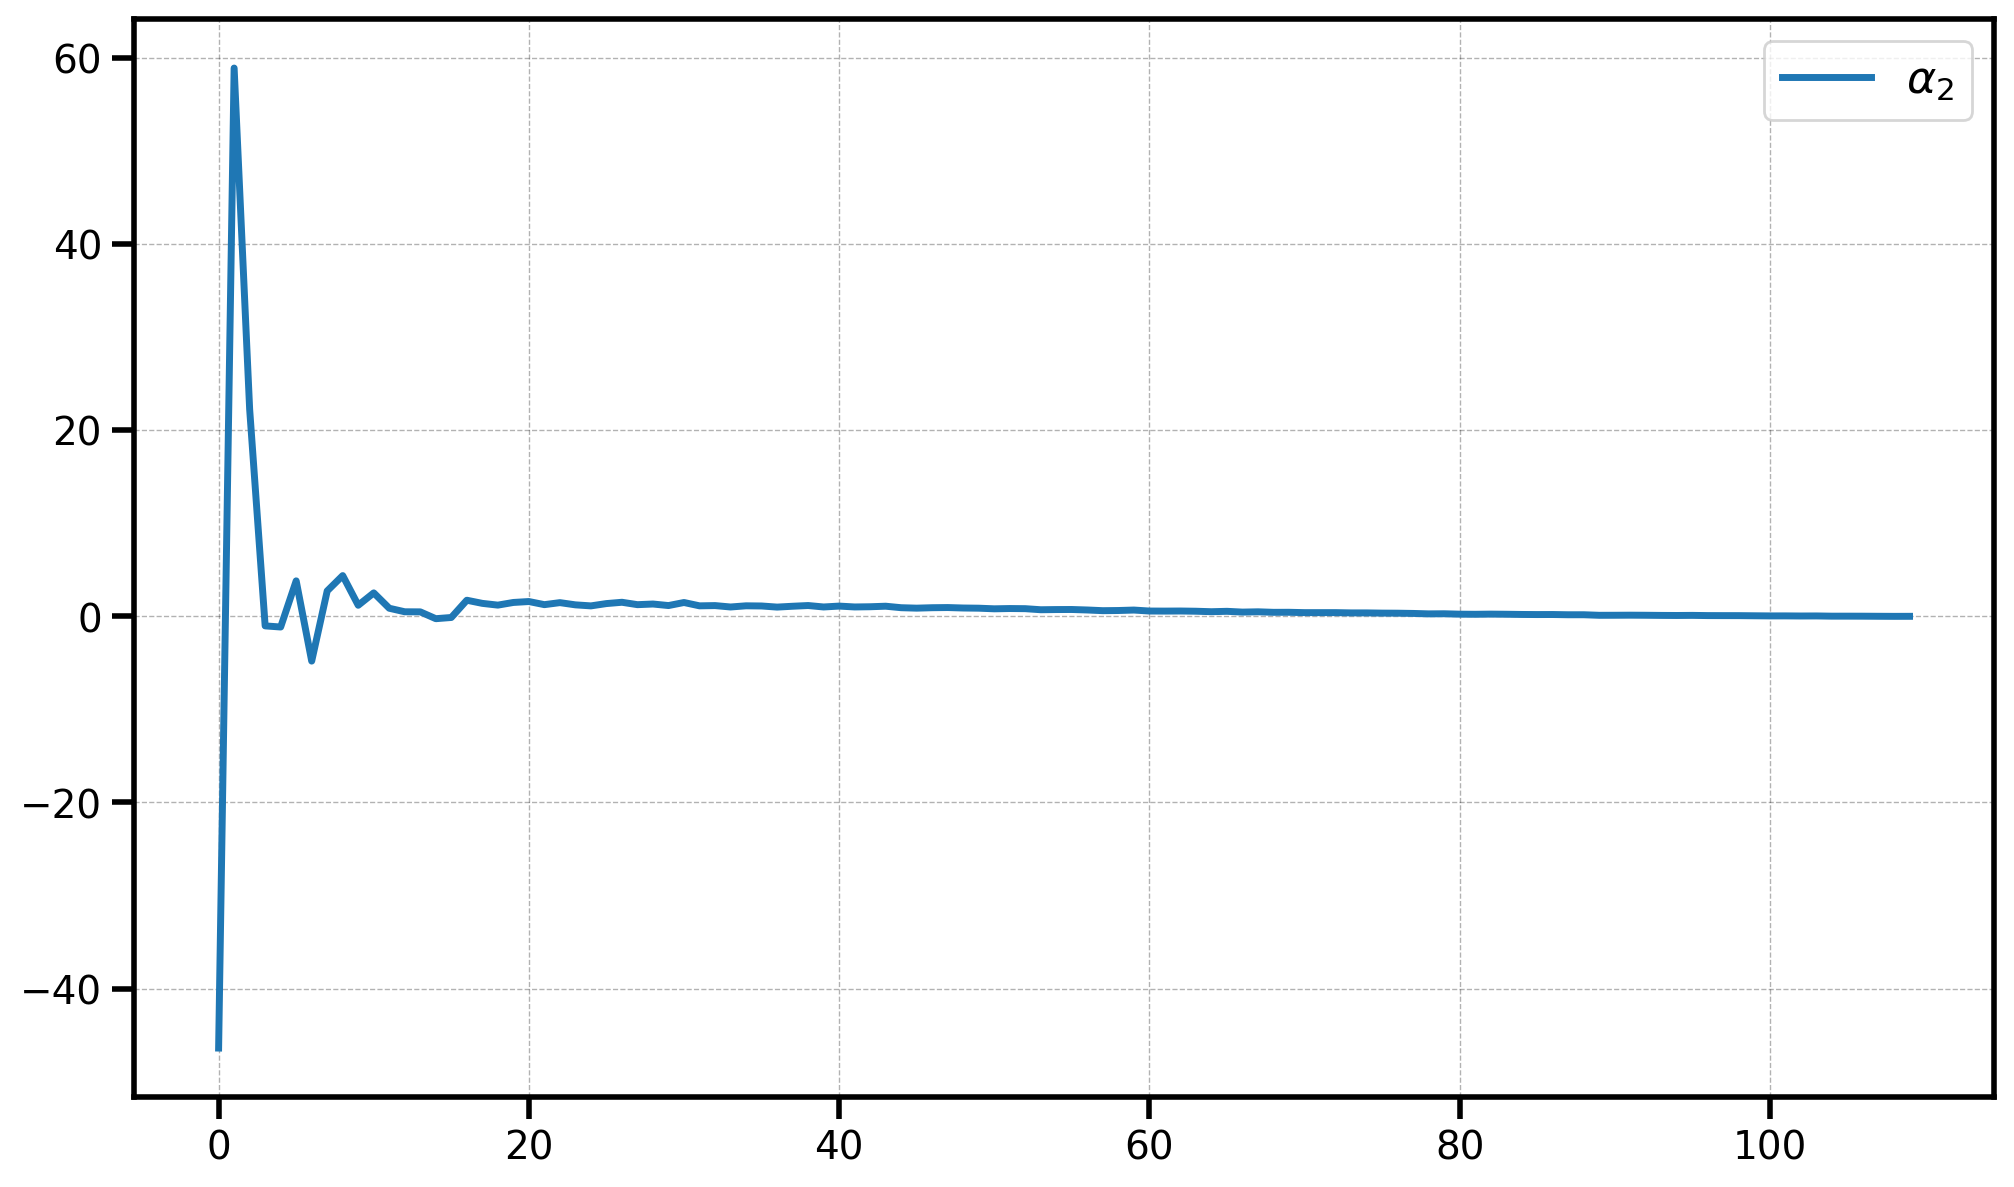

In [5]:
roots=get_roots(k, Pk0, Pk0_target)
# plt.plot(roots1[:,1].real, label='$\\alpha_1$')
plt.plot(roots[:,1].real, label='$\\alpha_2$')
# plt.loglog()
plt.legend()

In [6]:
grid=128

In [ ]:
freq = fftshift(fftfreq(grid, BoxSize/grid))
delta=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
delta_k = fftshift(fftn(delta)) #_mass

rad = np.zeros(3*[grid])
MAS_factor = np.zeros(3*[grid])
for x in range(grid):
    for y in range(grid):
        for z in range(grid):
            rad[x,y,z]=np.sqrt(freq[x]**2+freq[y]**2+freq[z]**2)
            MAS_factor[x,y,z]=MAS_correction(np.pi*BoxSize*freq[x]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[y]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[z]/grid, MAS_index)

delta_k=np.multiply(MAS_factor,delta_k)
            
binlist = np.linspace(rad.min(), rad.max(), int(0.5*grid*np.sqrt(3)))
index = np.digitize(rad, binlist)-1

weights = roots[:,1].real[:int(0.5*grid*np.sqrt(3))] #*np.sqrt(Pk0/Pk0_m)
phi_k = weights[index]*delta_k

a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize, threshold=1000./128)

delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

In [8]:
I=np.zeros([len(k), len(k)])
dz=1e-5
z=np.arange(-1,1+dz,dz)
for i,ki in enumerate(k):
    for j,qj in enumerate(k):

        k_in=np.sqrt(ki**2+qj**2-2*ki*qj*z)
        Pk_nl=np.interp(k_in, k, Pk0)
        if ki==qj:
            Pk_nl[-1]=0

        I[i,j]=8*np.pi**2*ki**2*qj**2*np.trapz(Pk_nl*z**2,z)

I2=np.identity(len(k))
for i, ki in enumerate(k):
    I2[i,i]*=ki**4

V=BoxSize**3
A=(I/V+I2)
a=np.matmul(A,Pk0)

I3=np.identity(len(k))
for i, ki in enumerate(k):
    I3[i,i]*=2*ki**2
b=np.matmul(I3,Pk0)

c=Pk0-Pk0_target

In [81]:
coeffs=np.column_stack([a,b,c])
roots=np.array([np.roots(coeffs[i]) for i in range(1,len(k))])

In [78]:
# roots=np.interp(k_, k[1:], roots[:,1].real)
# roots=np.row_stack([roots, np.array([0,0])])

In [88]:
freq = fftshift(fftfreq(grid, BoxSize/grid))
rx, ry, rz = np.meshgrid(freq, freq, freq)
rad = np.sqrt(rx**2+ry**2+rz**2)

MAS_factor = np.zeros(3*[grid])
for x in range(grid):
    for y in range(grid):
        for z in range(grid):
            MAS_factor[x,y,z]=MAS_correction(np.pi*BoxSize*freq[x]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[y]/grid, MAS_index)*MAS_correction(np.pi*BoxSize*freq[z]/grid, MAS_index)

delta_k = fftshift(fftn(np.array(delta)))
delta_k=np.multiply(MAS_factor,delta_k)

binlist = np.linspace(k.min(), k.max()+(k.max()-k.min())/(len(k)-1), len(k))
index = np.digitize(2*np.pi*rad, binlist)-1
roots=np.row_stack([roots, np.array([0,0])])

# binlist = np.linspace(rad.min(), rad.max(), 110)
# index = np.digitize(rad, binlist)-1

weights = roots[:,1].real
# weights = np.interp(k_, k[1:], roots[:,1].real)
phi_k = weights[index]*delta_k

a_x, a_y, a_z = calculate_acc_from_phi_k(phi_k, grid=grid, BoxSize=BoxSize)
pos_corrected = correct_pos(pos, a_x, a_y, a_z, grid=grid, BoxSize=BoxSize)

delta_corrected=get_delta_nbodykit(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=1000.0, compensated=compensated, MAS=MAS, interlaced=interlaced)
r = FFTPower(delta_corrected, mode='1d')
Pk0_corrected = r.power
k_corrected=Pk0_corrected['k']
Pk0_corrected=Pk0_corrected['power'].real


/home/x-abairagi/Projects/Power-Spectrum-Change-Under-Gradient-Perturbation/funcs.py:237: RuntimeWarning: invalid value encountered in cast
  i0 = np.floor(grid_pos).astype(int)%grid  # Base index per particle
/home/x-abairagi/Projects/Power-Spectrum-Change-Under-Gradient-Perturbation/funcs.py:254: RuntimeWarning: overflow encountered in add
  acc_at_particles += w[:, None]*acc[ix, iy, iz]
/home/x-abairagi/Projects/Power-Spectrum-Change-Under-Gradient-Perturbation/funcs.py:261: RuntimeWarning: invalid value encountered in remainder
  pos = pos%BoxSize


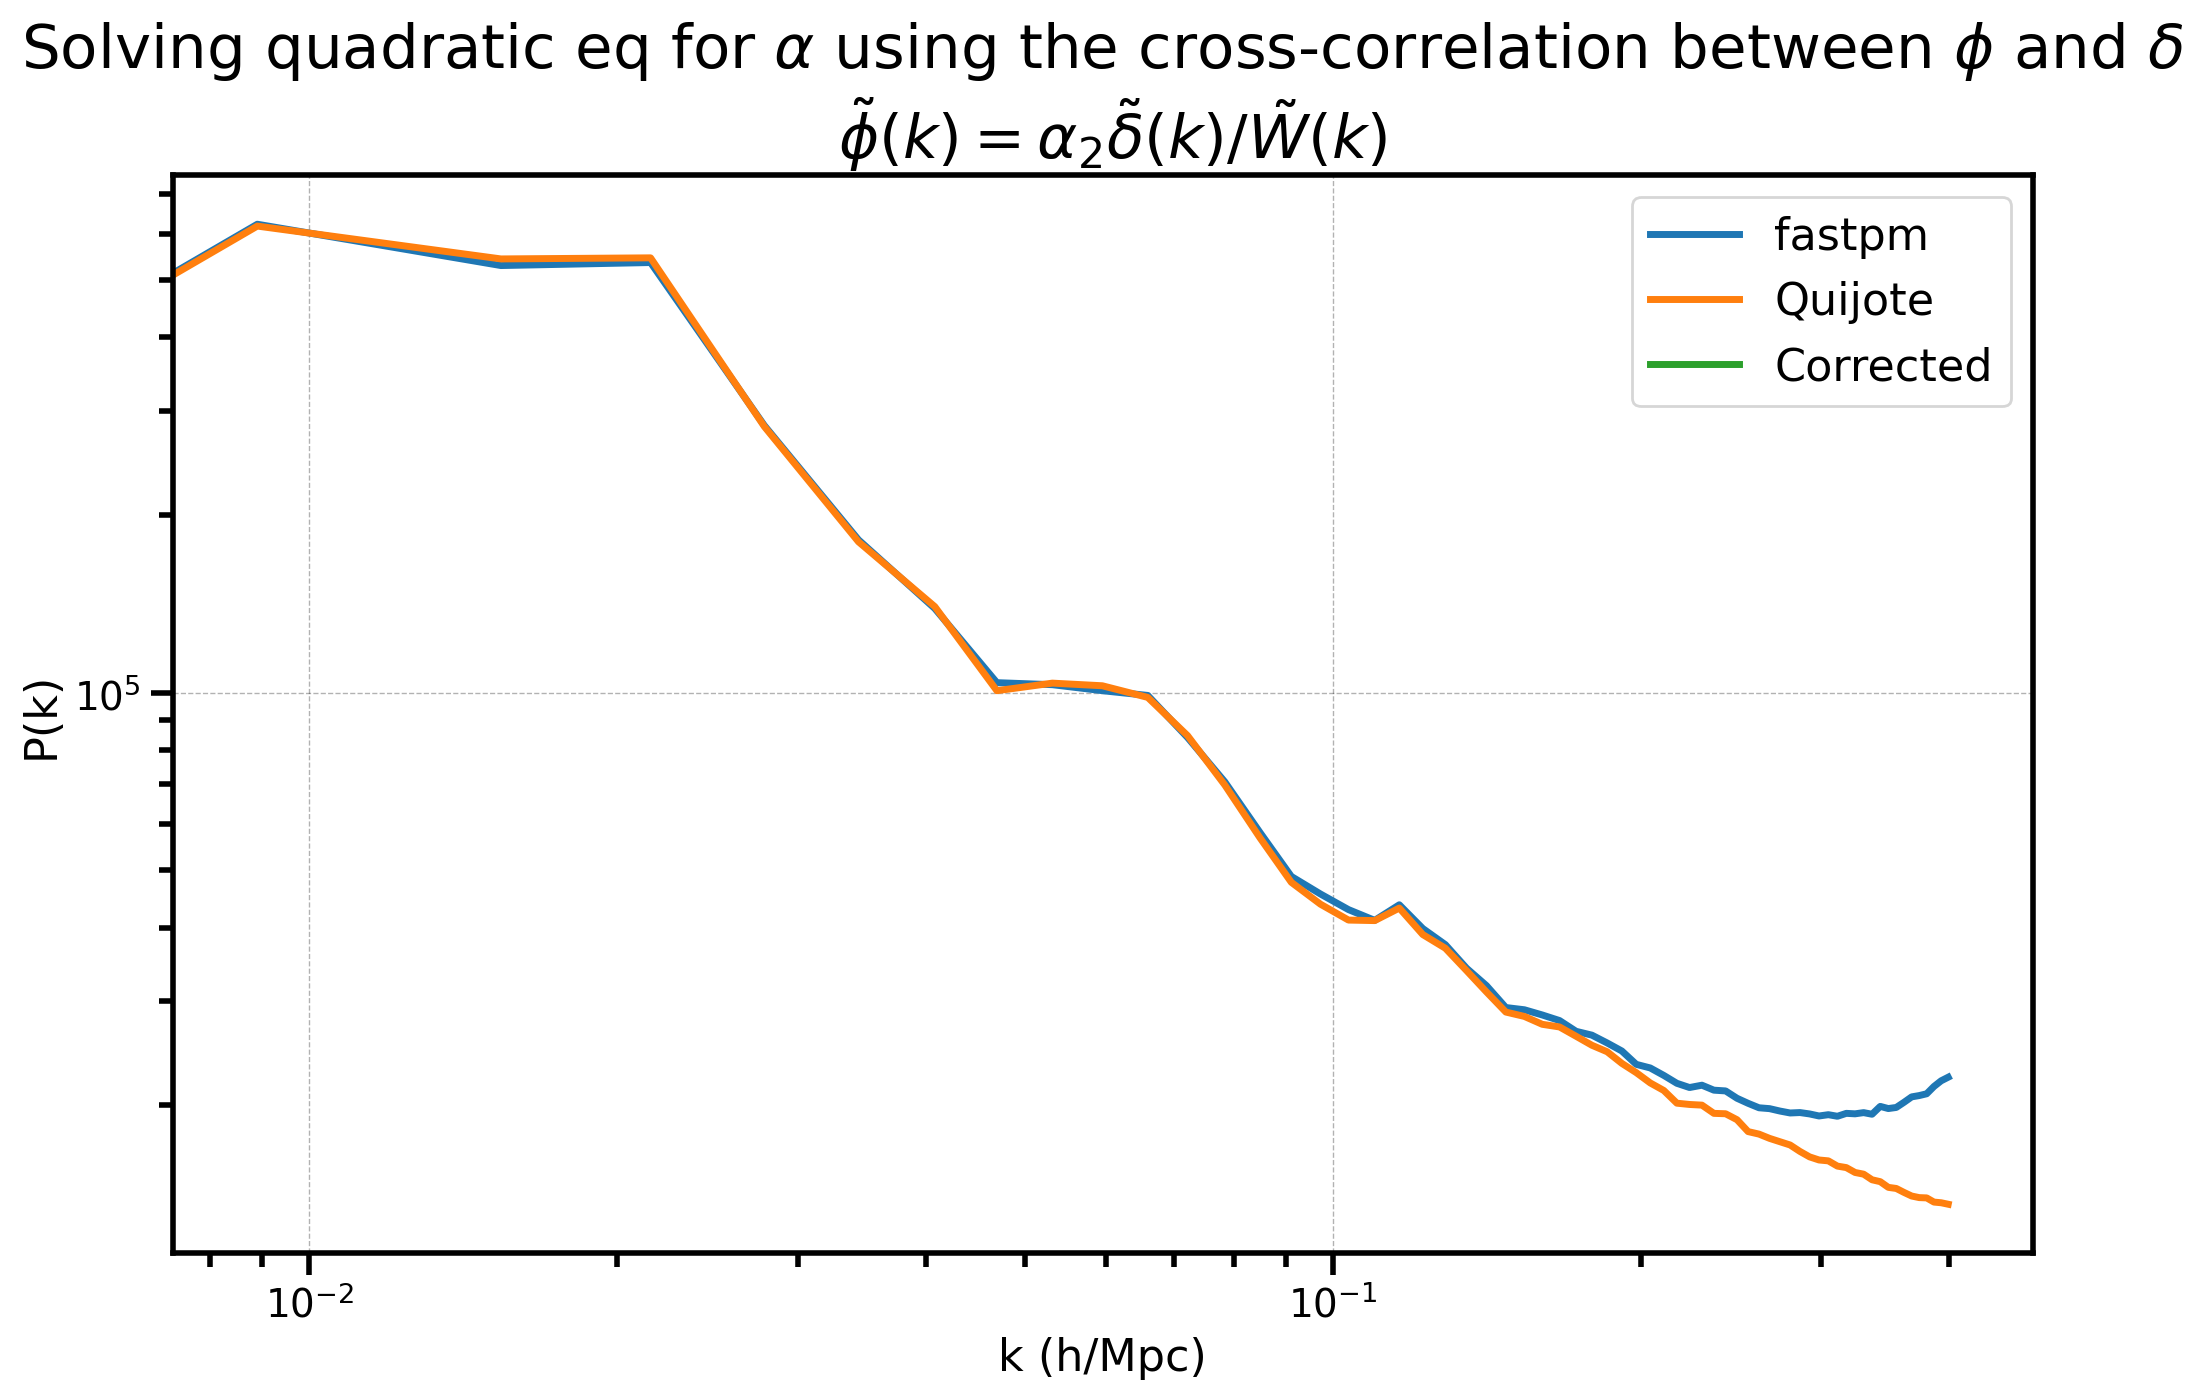

In [92]:
plt.plot(k, Pk0, label='fastpm')
plt.plot(k_target, Pk0_target, label='Quijote')
plt.plot(k_corrected, Pk0_corrected, label='Corrected')
plt.loglog()
plt.title("Solving quadratic eq for $\\alpha$ using the cross-correlation between $\phi$ and $\delta$\n $\\tilde{\phi}(k)=\\alpha_2\\tilde{\delta}(k)/\\tilde{W}(k)$")
plt.xlabel("k (h/Mpc)")
plt.ylabel("P(k)")
# plt.ylim([1,100000])
plt.legend()

In [ ]:
delta=get_delta(pos=pos, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k, Pk0, _, _ = compute_Pk(delta, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

# # Mass-weighted field
# delta_mass=get_delta(pos=pos, grid=grid, W=1, mass=mass, BoxSize=1000.0, MAS=MAS, verbose=True)
# k_m, Pk0_m, _, _ = compute_Pk(delta_mass, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)
# # Cross-Spectrum
# k_X, Pk0_X, _, _ = compute_XPk(delta_mass, delta, BoxSize=1000.0, MAS=[MAS, MAS] , axis=0)
# rk = Pk0_X/np.sqrt(Pk0*Pk0_m)

delta_target=get_delta(pos=pos_target, grid=grid, W=0, mass=1, BoxSize=1000.0, MAS=MAS, verbose=True)
k_target, Pk0_target, _, _ = compute_Pk(delta_target, BoxSize=1000.0, MAS=MAS, axis=0, verbose=True)

delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected, Pk0_corrected, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

## Rough

In [4]:
data = {'Position': pos}
catalog = ArrayCatalog(data)

# Paint onto mesh
mesh = catalog.to_mesh(Nmesh=grid, BoxSize=BoxSize, compensated=False, resampler='cic', interlaced=False)

# apply correction for the window to the mesh
# compensation = mesh.catalog.CompensateCIC #if window == 'CIC' else mesh.CompensateTSC
# mesh = mesh.apply(compensation, kind='circular', mode='complex')
delta = mesh.compute()-1
r = FFTPower(delta, mode='1d', dk=0.006, kmin=0.006)
Pk = r.power

In [36]:
# mesh.to_field()-mesh_both.to_field()

In [6]:
mesh_both = catalog.to_mesh(Nmesh=grid, BoxSize=BoxSize, compensated=True, resampler='cic', interlaced=True)
delta = mesh_both.compute()-1
r = FFTPower(delta, mode='1d', dk=0.006, kmin=0.006)
Pk1 = r.power

In [40]:
Pk1.attrs

{'Nmesh': array([128, 128, 128]),
 'BoxSize': array([1000., 1000., 1000.]),
 'Lx': 1000.0,
 'Ly': 1000.0,
 'Lz': 1000.0,
 'volume': 1000000000.0,
 'mode': '1d',
 'los': [0, 0, 1],
 'Nmu': 1,
 'poles': [],
 'dk': 0.006,
 'kmin': 0.006,
 'kmax': None,
 'N1': 0,
 'N2': 0,
 'shotnoise': 0}

In [23]:
Pk1.attrs['shotnoise']

0

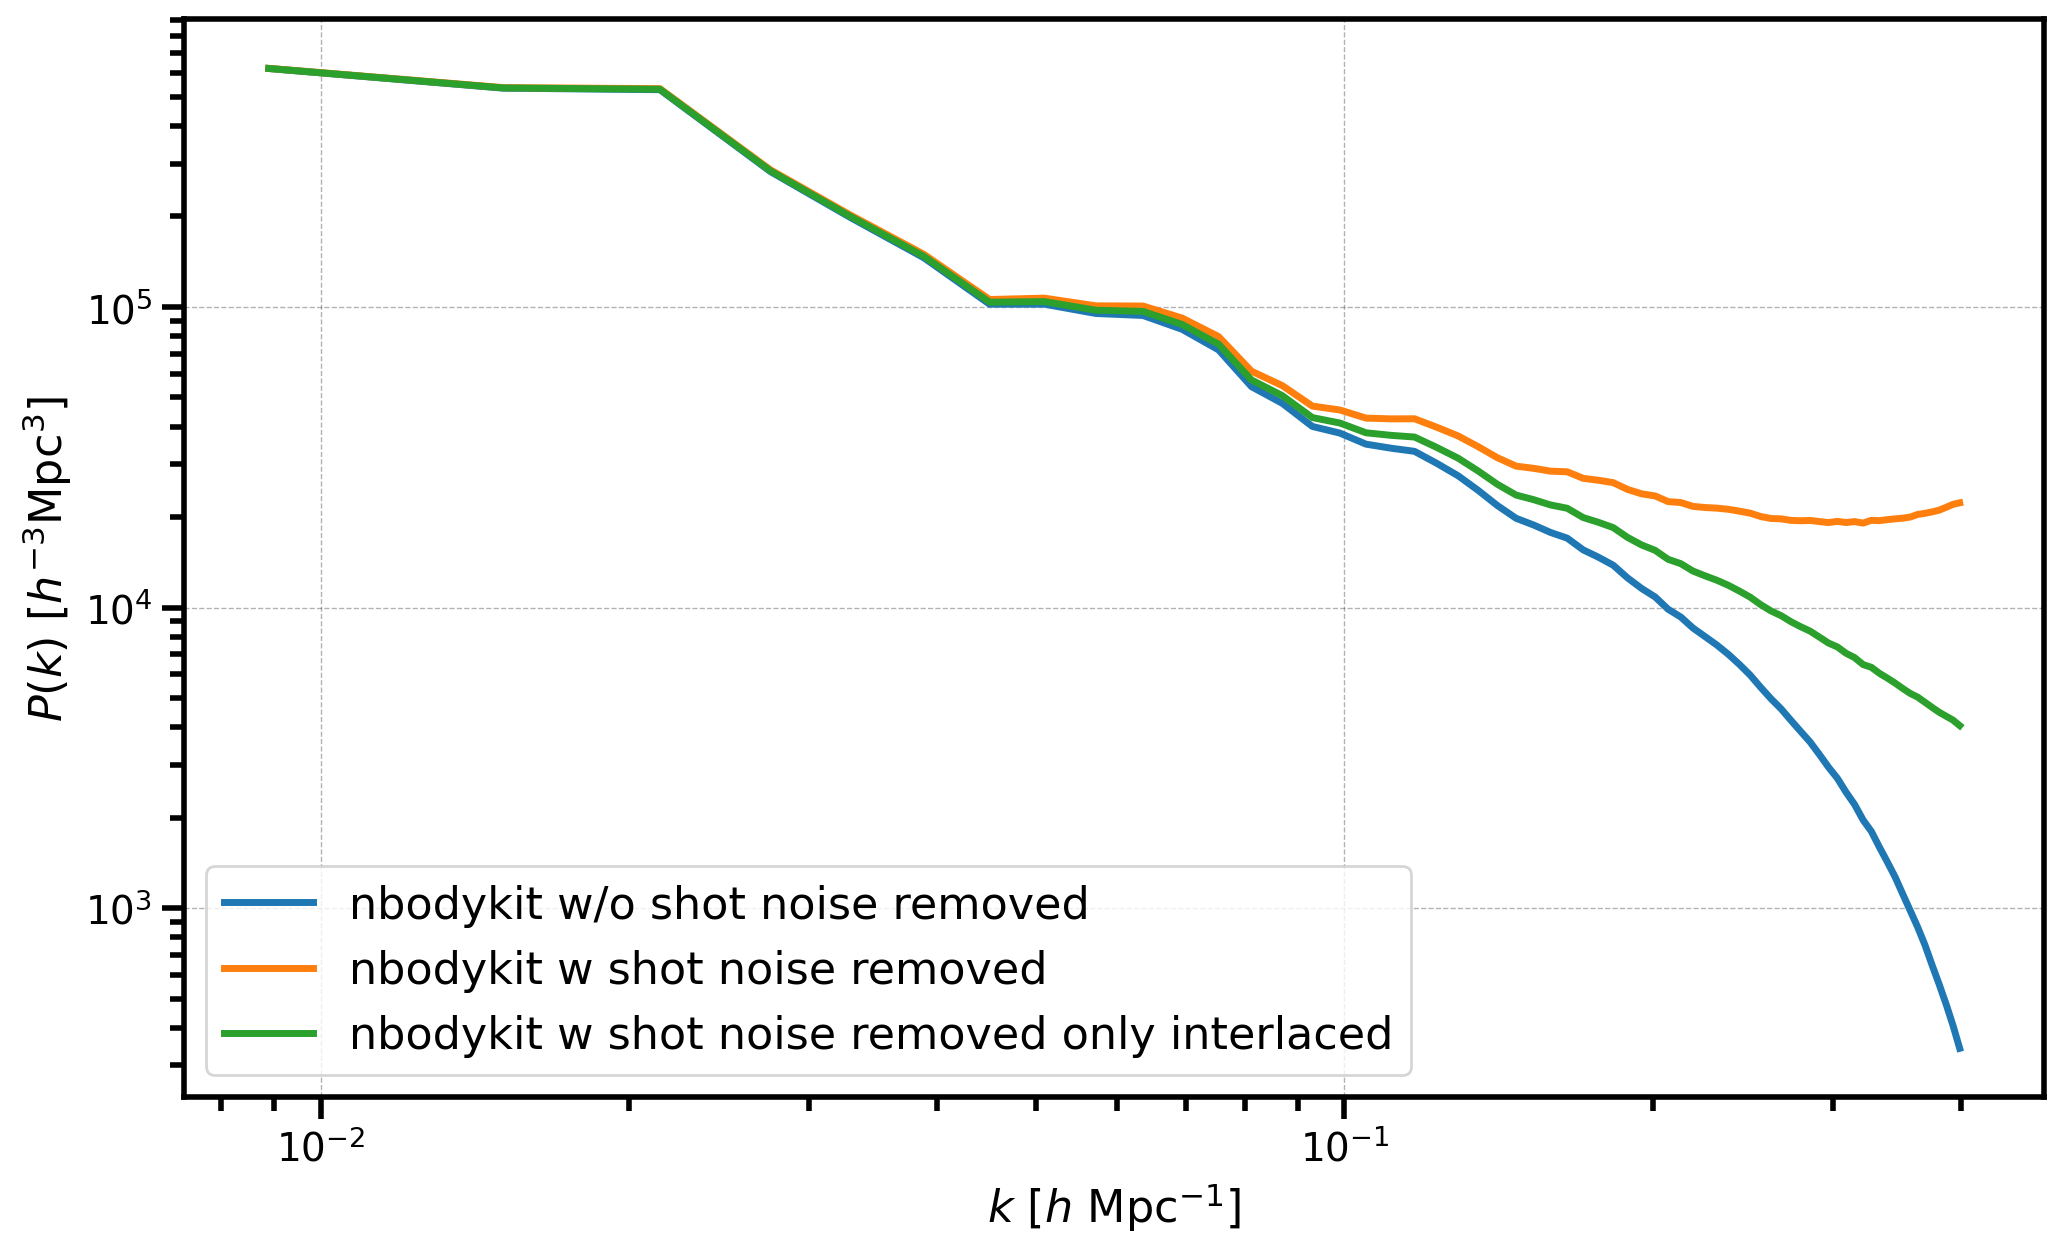

In [7]:
# print the shot noise subtracted P(k)
plt.loglog(Pk['k'], Pk['power'].real, label='nbodykit w/o shot noise removed')
plt.loglog(Pk1['k'], Pk1['power'].real, label='nbodykit w shot noise removed')
plt.loglog(Pk2['k'], Pk2['power'].real, label='nbodykit w shot noise removed only interlaced')
# plt.loglog(Pk['k'], Pk['power'].real - Pk.attrs['shotnoise'], label='nbodykit shot noise removed')
# plt.loglog(k_target, Pk0, label='pylians')

# format the axes
plt.xlabel(r"$k$ [$h \ \mathrm{Mpc}^{-1}$]")
plt.ylabel(r"$P(k)$ [$h^{-3}\mathrm{Mpc}^3$]")
plt.legend()
# plt.xlim(0.01, 0.6)

In [51]:
64*np.sqrt(3)

110.85125168440814

In [53]:
2*np.pi/1000

0.006283185307179587

In [ ]:
k